# Phase 2 - Weekly stochastic volatility and a daily threshold model

**Corrected version.** Every change with respect to the original notebook is listed, with references, in `CORRECTIONS.md`.

Phase 1 suggested that time-varying volatility explains a large part of the heavy tails. Here volatility becomes the object of study:

1. **Stochastic volatility (SV)** on weekly returns: volatility is a latent process inferred from the returns (Taylor, 1986; Kim, Shephard & Chib, 1998).
2. A **threshold AR(1) model** for daily log realized volatility, with a "normal" and a "crisis" regime (Tong & Lim, 1980), evaluated out of sample against simple benchmarks.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
from scipy import stats

SEED = 42
rng = np.random.default_rng(SEED)
os.makedirs("plots2", exist_ok=True)

# Frozen snapshot of daily prices (see Phase 1): no download at run time
daily = pd.read_csv("data/sp500_daily_2005_2025.csv", index_col="Date", parse_dates=True)
close_daily = daily["Close"]            # 1-D Series

# Weekly data analysis

Weekly prices are the last daily close of each week (Friday). Returns are in percent, $r_t = 100\,(\ln P_t - \ln P_{t-1})$, as is standard in the SV literature (Kim, Shephard & Chib, 1998, Sec. 2.2.1). Zero returns are **kept**: the likelihood is written on $r_t$, never on $\log r_t^2$, so they cause no numerical problem.

Weekly returns: 1095 (2005-01-14 -> 2025-12-31), shape (1095,)


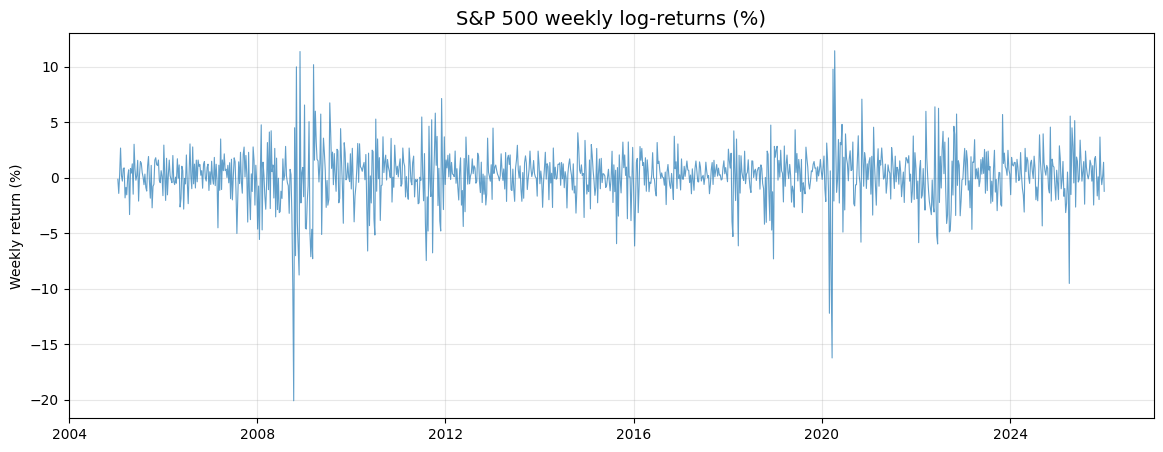

In [2]:
# Last trading day of each week (Monday-Friday), indexed by its actual date
close_weekly = close_daily.groupby(close_daily.index.to_period("W-FRI")).tail(1)
returns_weekly = (100 * np.log(close_weekly).diff()).dropna()

y = returns_weekly.values
dates = returns_weekly.index

# The original notebook used a (n, 1) DataFrame here: broadcast against the (n,)
# volatility vector it produced an (n, n) likelihood (see CORRECTIONS.md).
assert y.ndim == 1

print(f"Weekly returns: {len(y)} ({dates[0].date()} -> {dates[-1].date()}), shape {y.shape}")

plt.figure(figsize=(14, 5))
plt.plot(dates, y, alpha=0.7, lw=0.8)
plt.title("S&P 500 weekly log-returns (%)", fontsize=14)
plt.ylabel("Weekly return (%)")
plt.grid(True, alpha=0.3)
plt.savefig("plots2/phase2_exploratory.png", dpi=300, bbox_inches="tight")
plt.show()

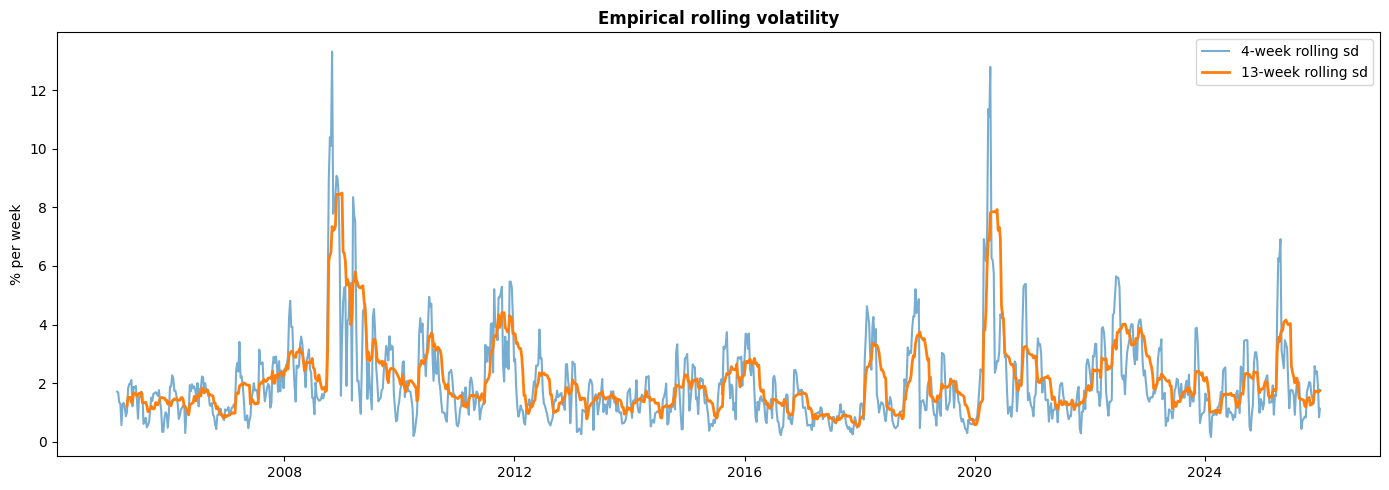

13-week rolling sd: min 0.518, max 8.494, ratio 16.4


In [3]:
# Empirical rolling volatility = rolling sd of the RETURNS
# (the original code took the rolling sd of |r|, which is not a volatility estimate)
roll_4 = returns_weekly.rolling(4).std()
roll_13 = returns_weekly.rolling(13).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(roll_4, alpha=0.6, label="4-week rolling sd")
ax.plot(roll_13, lw=2, label="13-week rolling sd")
ax.set_title("Empirical rolling volatility", fontsize=12, fontweight="bold")
ax.set_ylabel("% per week")
ax.legend()
plt.tight_layout()
plt.show()

print(f"13-week rolling sd: min {roll_13.min():.3f}, max {roll_13.max():.3f}, "
      f"ratio {roll_13.max() / roll_13.min():.1f}")

## Helper functions

Convergence is checked with rank-normalized $\hat R$ < 1.01, bulk/tail ESS > 400 and zero divergences (Vehtari et al., 2021), on the static parameters **and** on all the latent log-volatilities.

In [4]:
def check_convergence(trace, var_names, latent="h"):
    summary = az.summary(trace, var_names=var_names, round_to="none")
    n_div = int(trace.sample_stats["diverging"].sum())
    rhat_h = az.rhat(trace, var_names=[latent])[latent].values
    ess_h = az.ess(trace, var_names=[latent])[latent].values
    ok = (summary["r_hat"].max() < 1.01) and (summary["ess_bulk"].min() > 400) and n_div == 0 \
         and rhat_h.max() < 1.01 and ess_h.min() > 400
    print(f"  params: max R-hat {summary['r_hat'].max():.4f}, min ESS {summary['ess_bulk'].min():.0f} | "
          f"latent h: max R-hat {rhat_h.max():.4f}, min ESS {ess_h.min():.0f} | "
          f"divergences {n_div} -> {'✓ OK' if ok else '❌ CHECK'}")
    return summary


def plot_fit(trace, title, filename, transform):
    vol = transform(trace.posterior["h"])
    vol_mean = vol.mean(dim=("chain", "draw")).values
    vol_hdi = az.hdi(vol, hdi_prob=0.94)["h"].values

    fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax[0].plot(dates, y, color="black", alpha=0.4, lw=0.5)
    ax[0].set_title("S&P 500 weekly returns", fontsize=14)
    ax[0].set_ylabel("Return (%)")
    ax[1].plot(dates, vol_mean, color="#D62728", lw=1.5, label="Posterior mean")
    ax[1].fill_between(dates, vol_hdi[:, 0], vol_hdi[:, 1], color="#D62728", alpha=0.3, label="94% HDI")
    ax[1].set_title(title, fontsize=12, fontweight="bold")
    ax[1].set_ylabel("Conditional scale (% per week)")
    ax[1].legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(f"plots2/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

## Stochastic volatility model: random walk (original specification)

This is the **original** random-walk SV model with the **original priors**. The only change is that the data are now a 1-D vector.

In the original notebook this model produced a flat volatility, and the notebook blamed the prior on `sigma_h`. That led to a sequence of increasingly "forcing" priors (HalfNormal, Gamma(2, 5), Gamma(5, 10), a shifted `h_init` "to break symmetry"). The real cause was the shape bug: every observation was evaluated against every volatility. Choosing priors to force a desired posterior is poor practice, so those models are removed (Gelman et al., 2020, *Bayesian workflow*).

In [5]:
print(f"Building Stochastic Volatility Model for {len(y)} observations...")

with pm.Model() as model_sv:
    # Volatility of volatility (original prior)
    sigma_h = pm.Exponential("sigma_h", 5.0)

    # Latent log-volatility, non-centered random walk
    h_innovations_raw = pm.Normal("h_innovations_raw", 0, 1, shape=len(y) - 1)
    h_init = pm.Normal("h_init", mu=np.log(np.std(y)), sigma=0.5)
    h = pm.Deterministic("h", pm.math.concatenate([
        h_init[None],
        h_init + pm.math.cumsum(h_innovations_raw * sigma_h)
    ]))

    # Here h is the log of the conditional scale: sd_t = exp(h_t)
    nu = pm.Gamma("nu", alpha=2, beta=0.1)
    obs = pm.StudentT("obs", nu=nu, mu=0, sigma=pm.math.exp(h), observed=y)

    trace_sv = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, random_seed=SEED)

summary_sv = check_convergence(trace_sv, ["sigma_h", "nu", "h_init"])
print(summary_sv[["mean", "sd", "hdi_3%", "hdi_97%"]])

Building Stochastic Volatility Model for 1095 observations...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_h, h_innovations_raw, h_init, nu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 92 seconds.


  params: max R-hat 1.0008, min ESS 1357 | latent h: max R-hat 1.0035, min ESS 3244 | divergences 0 -> ✓ OK
              mean         sd     hdi_3%    hdi_97%
sigma_h   0.113262   0.014744   0.087347   0.142278
nu       31.040054  13.986626  10.511796  56.878100
h_init    0.402319   0.262450  -0.076062   0.897226


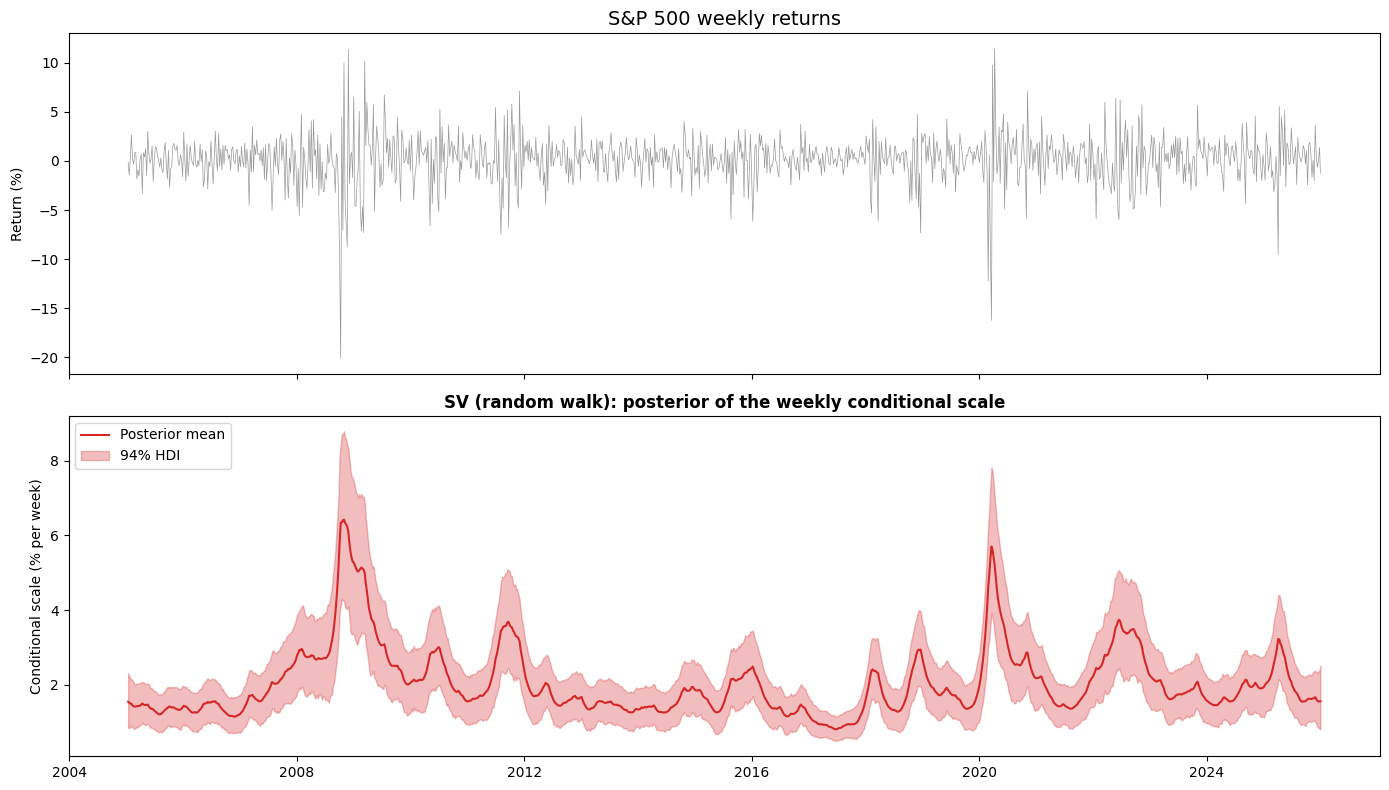

In [6]:
plot_fit(trace_sv, "SV (random walk): posterior of the weekly conditional scale",
         "sv_random_walk.png", transform=np.exp)

## Stochastic volatility model: stationary AR(1) (canonical SV)

The original notebook fixed $\phi$ = 0.95 and used a centered parameterization, which produced 308 divergences. Here $\phi$ is **estimated** and $h_t$ is non-centered (Betancourt & Girolami, 2015; Stan User's Guide, *Stochastic volatility models*):

$$ h_t = \mu + \phi (h_{t-1} - \mu) + \sigma_\eta \eta_t, \qquad r_t \sim t_\nu\big(0, e^{h_t/2}\big), $$

with $h$ the log-**variance** and the priors of Kim, Shephard & Chib (1998, Sec. 2.2.1): $\mu \sim N(0, 10)$, $(\phi+1)/2 \sim \text{Beta}(20, 1.5)$, $\sigma_\eta^2 \sim \text{Inv-Gamma}(2.5, 0.025)$. The Student-t innovations follow Jacquier, Polson & Rossi (2004), with $\nu \sim \text{Gamma}(2, 0.1)$ (Juárez & Steel, 2010).

In [7]:
with pm.Model() as model_ar1:
    mu = pm.Normal("mu", mu=0, sigma=np.sqrt(10))
    phi = pm.Deterministic("phi", 2 * pm.Beta("phi_star", alpha=20, beta=1.5) - 1)
    sigma_eta = pm.Deterministic("sigma_eta", pt.sqrt(pm.InverseGamma("sigma2_eta", alpha=2.5, beta=0.025)))

    # Non-centered AR(1): x_1 from the stationary distribution, then the recursion
    eta = pm.Normal("eta", 0, 1, shape=len(y))
    x_1 = eta[0] * sigma_eta / pt.sqrt(1 - phi**2)
    x_rest, _ = pytensor.scan(lambda e, x_prev, phi, s: phi * x_prev + s * e,
                              sequences=[eta[1:]], outputs_info=[x_1], non_sequences=[phi, sigma_eta])
    h = pm.Deterministic("h", mu + pt.concatenate([x_1[None], x_rest]))

    nu = pm.Gamma("nu", alpha=2, beta=0.1)
    obs = pm.StudentT("obs", nu=nu, mu=0, sigma=pm.math.exp(h / 2), observed=y)

    trace_ar1 = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, random_seed=SEED)

summary_ar1 = check_convergence(trace_ar1, ["mu", "phi", "sigma_eta", "nu"])
print(summary_ar1[["mean", "sd", "hdi_3%", "hdi_97%"]])

phi_s = trace_ar1.posterior["phi"].values.flatten()
print(f"\nHalf-life of a volatility shock: {np.mean(np.log(0.5) / np.log(phi_s)):.1f} weeks")

/var/folders/kv/zt7j48t16bxdjlpfww8l32t00000gn/T/ipykernel_25611/646116776.py:9: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_rest, _ = pytensor.scan(lambda e, x_prev, phi, s: phi * x_prev + s * e,
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, phi_star, sigma2_eta, eta, nu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 722 seconds.


  params: max R-hat 1.0026, min ESS 1813 | latent h: max R-hat 1.0040, min ESS 4186 | divergences 0 -> ✓ OK
                mean         sd     hdi_3%    hdi_97%
mu          1.203859   0.187487   0.848415   1.560353
phi         0.948143   0.015179   0.919629   0.974673
sigma_eta   0.281912   0.037704   0.209358   0.350350
nu         35.178794  15.122091  11.395213  62.013792

Half-life of a volatility shock: 14.3 weeks


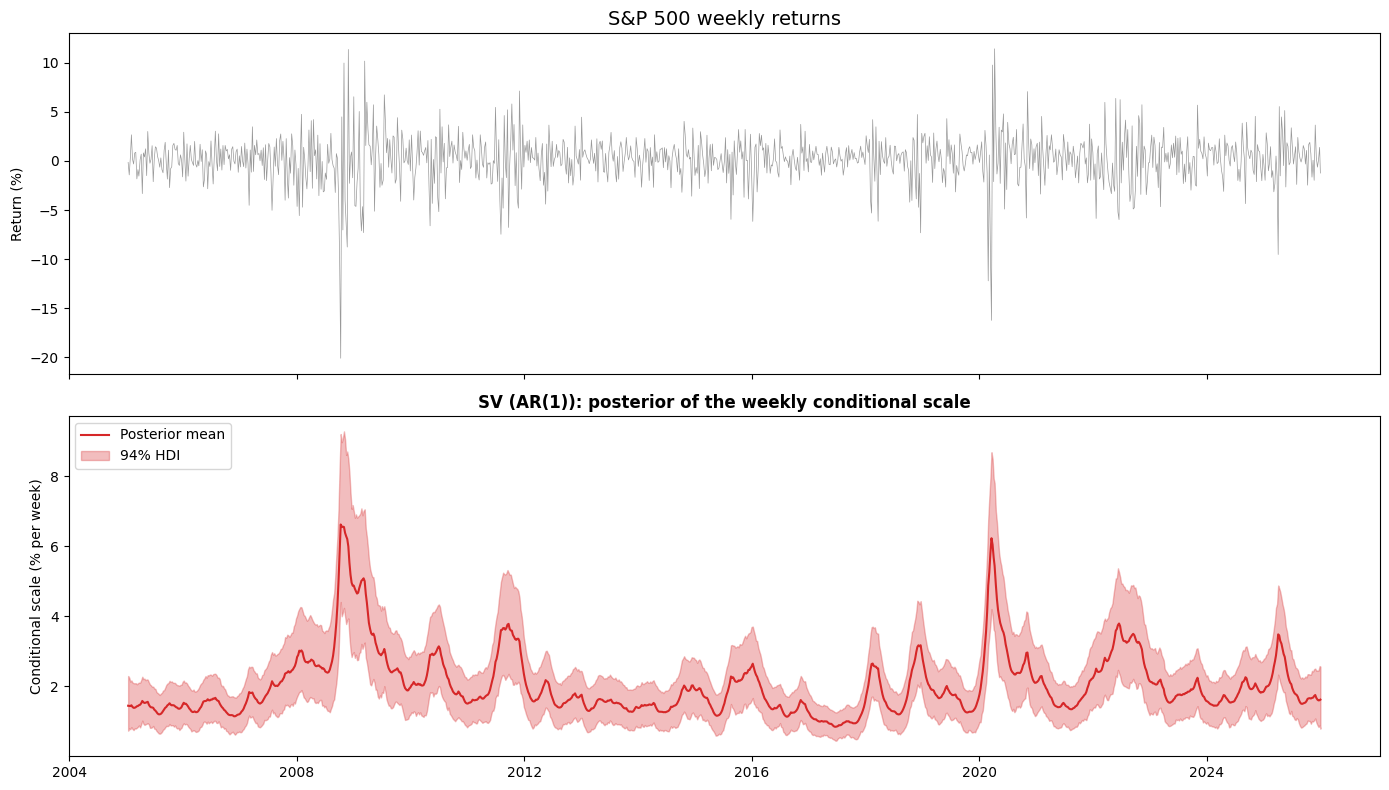

In [8]:
plot_fit(trace_ar1, "SV (AR(1)): posterior of the weekly conditional scale",
         "sv_ar1.png", transform=lambda h: np.exp(h / 2))

# Threshold model on daily data

### Data and realized volatility

Daily percentage log-returns (zero returns kept). Realized volatility $RV_t$ is the sd of the last 5 daily returns, computed on the whole series and then split by date, so the first test days use only past data. The original code computed it separately on each split and dropped the first 4 test days.

Note: consecutive 5-day windows share 4 returns, so part of the persistence of $\log RV_t$ is **mechanical**. This is why the naive forecast "tomorrow = today" is a demanding benchmark.

* Estimation: 2005-2022. Test: 2023-2025.
* $h_t = \log RV_t - \overline{\log RV}_{train}$ (centering with training data only).

In [10]:
returns_daily = (100 * np.log(close_daily).diff()).dropna()

rv = returns_daily.rolling(5).std().dropna()
h_all = np.log(rv)

split_date = "2022-12-31"
h_mean_train = h_all[:split_date].mean()
h_all = h_all - h_mean_train

# Threshold: 90th percentile of the TRAINING realized volatility (as in the original project)
gamma = rv[:split_date].quantile(0.90)

# Lagged regime: S_t = 1 if RV_{t-1} > gamma (self-exciting threshold with delay 1; Tong & Lim, 1980).
# The original code used RV_t itself, i.e. the regime of the target was known in advance.
regime_all = (rv.shift(1) > gamma).astype(int)

# Build (h_{t-1}, h_t, S_t) triples and split them by the date of h_t
frame = pd.DataFrame({"h": h_all, "h_lag": h_all.shift(1), "regime": regime_all}).dropna()
train = frame[:split_date]
test = frame[frame.index > split_date]

print(f"Train: {len(train)} days ({train.index[0].date()} -> {train.index[-1].date()}), "
      f"crisis share {train['regime'].mean():.3f}")
print(f"Test:  {len(test)} days ({test.index[0].date()} -> {test.index[-1].date()}), "
      f"crisis share {test['regime'].mean():.3f}")
print(f"Threshold gamma (RV, % per day): {gamma:.3f}")

Train: 4525 days (2005-01-11 -> 2022-12-30), crisis share 0.100
Test:  752 days (2023-01-03 -> 2025-12-31), crisis share 0.024
Threshold gamma (RV, % per day): 1.781


### Models

**Threshold AR(1).** $h_t = \mu_{S_t} + \phi_{S_t} h_{t-1} + \varepsilon_t$, with $\varepsilon_t \sim t_\nu(0, \sigma_{S_t})$. The regime-specific priors are kept from the original project. $\phi \sim \text{Beta}(20, 2)$ encodes **high persistence**, i.e. *slow* mean reversion (the original description, "strong mean reversion", said the opposite). $\nu \sim \text{Gamma}(2, 0.1)$ replaces Exponential(1/10).

**Benchmark 1: single-regime AR(1)**, the same model without regimes. It tests whether the threshold adds anything.

**Benchmark 2: persistence** $\hat h_t = h_{t-1}$ (no parameters).

In [11]:
def fit_threshold(data, n_regimes):
    s = data["regime"].values if n_regimes == 2 else np.zeros(len(data), dtype=int)
    with pm.Model() as model:
        if n_regimes == 2:
            mu = pm.Normal("mu", mu=np.array([-0.5, 0.5]), sigma=1, shape=2)            # [normal, crisis]
            phi = pm.Beta("phi", alpha=np.array([20, 15]), beta=np.array([2, 3]), shape=2)
            sigma = pm.HalfNormal("sigma", sigma=np.array([0.3, 0.5]), shape=2)
        else:
            mu = pm.Normal("mu", mu=0, sigma=1, shape=1)
            phi = pm.Beta("phi", alpha=20, beta=2, shape=1)
            sigma = pm.HalfNormal("sigma", sigma=0.5, shape=1)
        nu = pm.Gamma("nu", alpha=2, beta=0.1)
        pm.StudentT("obs", nu=nu, mu=mu[s] + phi[s] * data["h_lag"].values, sigma=sigma[s],
                    observed=data["h"].values)
        trace = pm.sample(2000, tune=1000, chains=4, target_accept=0.95, random_seed=SEED)
    summary = az.summary(trace, var_names=["mu", "phi", "sigma", "nu"], round_to="none")
    n_div = int(trace.sample_stats["diverging"].sum())
    print(f"  max R-hat {summary['r_hat'].max():.4f} | min ESS {summary['ess_bulk'].min():.0f} | divergences {n_div}")
    return trace, summary

print("Threshold AR(1) (2 regimes)")
trace_thr, summary_thr = fit_threshold(train, n_regimes=2)
print(summary_thr[["mean", "sd", "hdi_3%", "hdi_97%"]].round(3))

print("\nSingle-regime AR(1)")
trace_one, summary_one = fit_threshold(train, n_regimes=1)
print(summary_one[["mean", "sd", "hdi_3%", "hdi_97%"]].round(3))

Initializing NUTS using jitter+adapt_diag...


Threshold AR(1) (2 regimes)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, phi, sigma, nu]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.
Initializing NUTS using jitter+adapt_diag...


  max R-hat 1.0011 | min ESS 3623 | divergences 0
           mean     sd  hdi_3%  hdi_97%
mu[0]     0.001  0.003  -0.004    0.007
mu[1]     0.010  0.019  -0.026    0.046
phi[0]    0.954  0.006   0.944    0.965
phi[1]    0.965  0.014   0.939    0.991
sigma[0]  0.150  0.004   0.142    0.158
sigma[1]  0.125  0.007   0.111    0.139
nu        1.838  0.084   1.687    2.001

Single-regime AR(1)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, phi, sigma, nu]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.


  max R-hat 1.0007 | min ESS 4211 | divergences 0
           mean     sd  hdi_3%  hdi_97%
mu[0]     0.003  0.003  -0.002    0.008
phi[0]    0.961  0.004   0.954    0.969
sigma[0]  0.146  0.004   0.138    0.153
nu        1.811  0.081   1.662    1.965


**Reading $\nu$.** In this model $\nu$ is the tail parameter of the innovations of $\log RV_t$, not of the returns. Values below 2 mean innovations with infinite variance. This is a symptom of the overlapping-window construction: a single large return makes $\log RV$ jump when it enters the 5-day window and drop when it leaves it 5 days later. Range-based daily estimators (Parkinson, 1980; Garman & Klass, 1980) would avoid this, but they are outside the scope of this correction.

### Out-of-sample one-step-ahead forecast (2023-2025)

Parameters are estimated on 2005-2022 only. The regime of day $t$ uses $RV_{t-1}$, exactly as in estimation. For each test day we compute the posterior predictive distribution of $h_t$ and score it with:

* **MAE** of the predictive mean (also for the persistence benchmark);
* **empirical coverage** of the central 90% predictive interval (should be ≈ 90%);
* **mean log predictive density**, a proper scoring rule (Gneiting & Raftery, 2007). Higher is better.

In [12]:
def one_step_forecast(trace, data, n_regimes, n_draws=4000):
    post = trace.posterior.stack(sample=("chain", "draw"))
    idx = rng.choice(post.sizes["sample"], n_draws, replace=False)
    s = data["regime"].values if n_regimes == 2 else np.zeros(len(data), dtype=int)

    mu = post["mu"].values[:, idx].T[:, s]          # (draws, days)
    phi = post["phi"].values[:, idx].T[:, s]
    sigma = post["sigma"].values[:, idx].T[:, s]
    nu = post["nu"].values[idx][:, None]

    loc = mu + phi * data["h_lag"].values[None, :]
    sims = loc + sigma * rng.standard_t(nu, size=loc.shape)
    lo, hi = np.percentile(sims, [5, 95], axis=0)
    obs = data["h"].values

    lpd = np.log(stats.t.pdf(obs[None, :], nu, loc, sigma).mean(axis=0))
    return {"mean": sims.mean(axis=0), "lo": lo, "hi": hi,
            "MAE": np.mean(np.abs(obs - sims.mean(axis=0))),
            "90% coverage": np.mean((obs >= lo) & (obs <= hi)),
            "mean log pred. density": lpd.mean()}

fc_thr = one_step_forecast(trace_thr, test, 2)
fc_one = one_step_forecast(trace_one, test, 1)

results = pd.DataFrame({
    "Threshold AR(1)": {k: fc_thr[k] for k in ["MAE", "90% coverage", "mean log pred. density"]},
    "Single-regime AR(1)": {k: fc_one[k] for k in ["MAE", "90% coverage", "mean log pred. density"]},
    "Persistence (h_t = h_t-1)": {"MAE": np.mean(np.abs(test["h"] - test["h_lag"])),
                                  "90% coverage": np.nan, "mean log pred. density": np.nan},
}).T
print(results.round(4).to_string())

                              MAE  90% coverage  mean log pred. density
Threshold AR(1)            0.1941         0.887                 -0.0644
Single-regime AR(1)        0.1943         0.887                 -0.0641
Persistence (h_t = h_t-1)  0.1966           NaN                     NaN


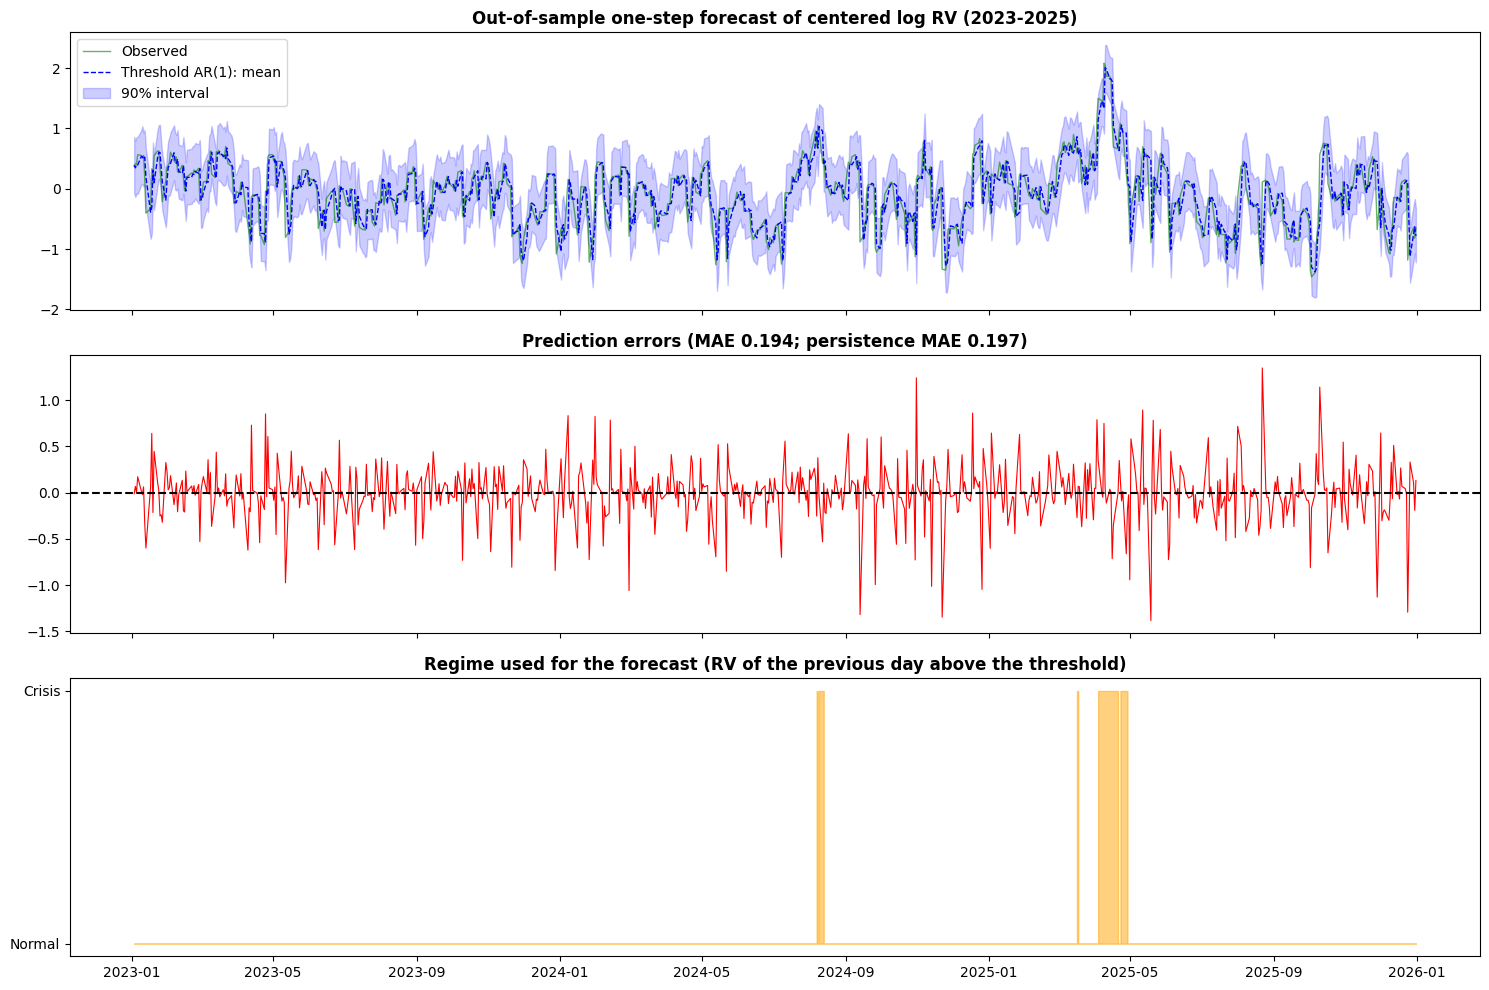

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(test.index, test["h"], "g-", lw=1, alpha=0.6, label="Observed")
axes[0].plot(test.index, fc_thr["mean"], "b--", lw=1, label="Threshold AR(1): mean")
axes[0].fill_between(test.index, fc_thr["lo"], fc_thr["hi"], color="blue", alpha=0.2, label="90% interval")
axes[0].set_title("Out-of-sample one-step forecast of centered log RV (2023-2025)", fontsize=12, fontweight="bold")
axes[0].legend(loc="upper left")

errors = test["h"].values - fc_thr["mean"]
axes[1].plot(test.index, errors, "r-", lw=0.8)
axes[1].axhline(0, color="k", ls="--")
axes[1].set_title(f"Prediction errors (MAE {fc_thr['MAE']:.3f}; persistence MAE "
                  f"{results.loc['Persistence (h_t = h_t-1)', 'MAE']:.3f})", fontsize=12, fontweight="bold")

axes[2].fill_between(test.index, 0, test["regime"], color="orange", alpha=0.5, step="post")
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(["Normal", "Crisis"])
axes[2].set_title("Regime used for the forecast (RV of the previous day above the threshold)",
                  fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("plots2/threshold_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

### Crisis-regime days in the test period

Dates are taken from the index of the realized-volatility series itself. The original code truncated a longer date vector and shifted every label by 4 trading days. Because the regime uses $RV_{t-1}$, a day is flagged **after** a volatility spike has been observed: the model reacts to crises and does not anticipate them.

In [14]:
crisis = test[test["regime"] == 1]
print(f"Crisis-regime days: {len(crisis)} of {len(test)} ({len(crisis) / len(test):.1%})")
if len(crisis) > 0:
    runs = (crisis.index.to_series().diff() > pd.Timedelta(days=5)).cumsum()
    for _, block in crisis.groupby(runs):
        print(f"  {block.index[0].date()} -> {block.index[-1].date()} ({len(block)} days)")

Crisis-regime days: 18 of 752 (2.4%)
  2024-08-07 -> 2024-08-12 (3 days)
  2025-03-17 -> 2025-03-17 (1 days)
  2025-04-04 -> 2025-04-17 (10 days)
  2025-04-23 -> 2025-04-28 (4 days)


## Summary of Phase 2 (to be filled with the numbers above)

Report:
1. SV: whether the posterior volatility varies over time, $\phi$ and the half-life, and $\nu$ vs its prior;
2. threshold model vs single-regime AR(1) vs persistence: MAE, coverage and log score. The regimes are useful only if they beat the single-regime benchmark;
3. the crisis episodes flagged in the test period, with their correct dates, keeping in mind that the signal is lagged by construction.